# Check preprocessing transforms

Load the dataset indicated by the default configs, plot some raw values, set
up the preprocessing transformations for both the conditioning and the
features, then transform the data and plot it.

In [1]:
import copy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

# make the ``src`` package importable
repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

from src.data.read_write import read_raw_regaxes
from src.data.transforms import preprocessing
from src.data.dataset import from_config as dataset_from_config

## Load the default configuration

In [2]:
config_path = repo_root / "config" / "showerdata.yaml"
with open(config_path) as f:
    configs = yaml.safe_load(f)


## Load the dataset

In [3]:
# read the raw events (in local xyze order) via the common read interface
cond_features = configs["model"]["cond_features"]
col_names = [configs['data'][f'{name}_key'] for name in cond_features]
per_event, events = read_raw_regaxes(configs, part="train", total_size=100, per_event_cols=col_names)

print("per_event shape:", per_event.shape)
print("events shape:", events.shape)

Selecting evenly spaced events
per_event shape: (100, 4)
events shape: (100, 6016, 4)


## Pick out the raw features and conditioning

In [4]:
def to_tensor(value):
    if isinstance(value, torch.Tensor):
        return value.float()
    return torch.as_tensor(np.asarray(value)).float()


# the point cloud (features) is the events array in xyze order
features = to_tensor(events)

# the conditioning is the incident energy of each event
cond_feats = to_tensor(per_event)

print("features shape:", tuple(features.shape))
print("conditioning shape:", tuple(cond_feats.shape))

features shape: (100, 6016, 4)
conditioning shape: (100, 4)


## Plot the raw values

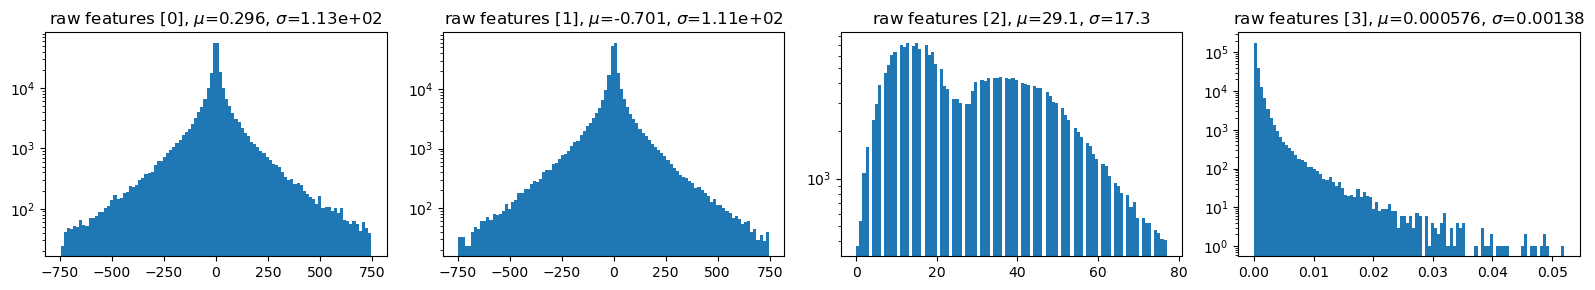

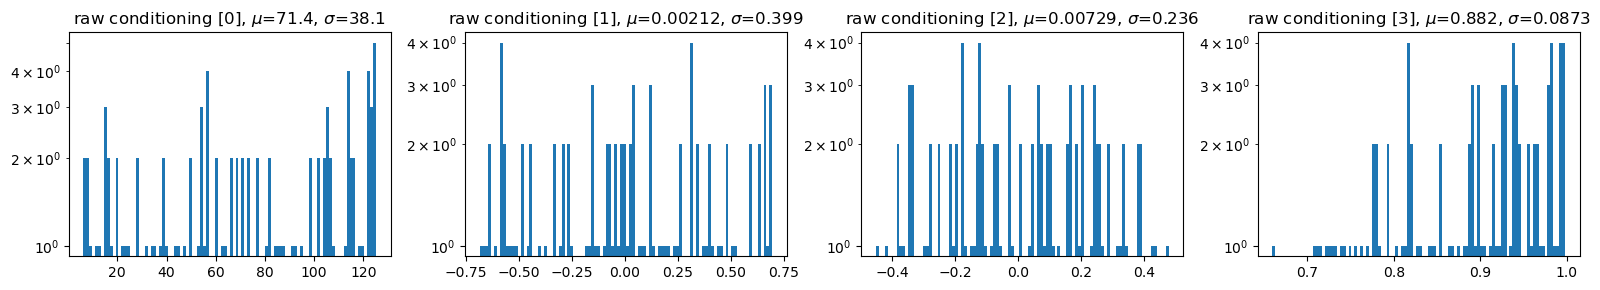

In [5]:
def plot_columns(data, title):
    data = to_tensor(data)
    data = data.reshape(-1, data.shape[-1])
    n_cols = data.shape[-1]
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3))
    axes = np.atleast_1d(axes)
    for i, ax in enumerate(axes):
        vals = data[:, i].detach().cpu().numpy()
        ax.hist(vals, bins=100)
        mean = np.mean(vals)
        std = np.std(vals)
        ax.set_title(f"{title} [{i}], $\\mu$={mean:.3}, $\\sigma$={std:.3}")
        ax.semilogy()
    fig.tight_layout()
    return fig

real_features = features[features[..., 3]>0]
plot_columns(real_features, "raw features")
plot_columns(cond_feats, "raw conditioning")
plt.show()

## Set up the preprocessing transformations

In [6]:
feature_transform = preprocessing(configs, "features")
cond_transform = preprocessing(configs, "conditioning")

feature_transform, cond_transform

(Sequence(
   (sub_modules): ModuleList(
     (0): Partial()
   )
 ),
 Sequence(
   (sub_modules): ModuleList(
     (0): Partial()
   )
 ))

## Transform the data and plot it

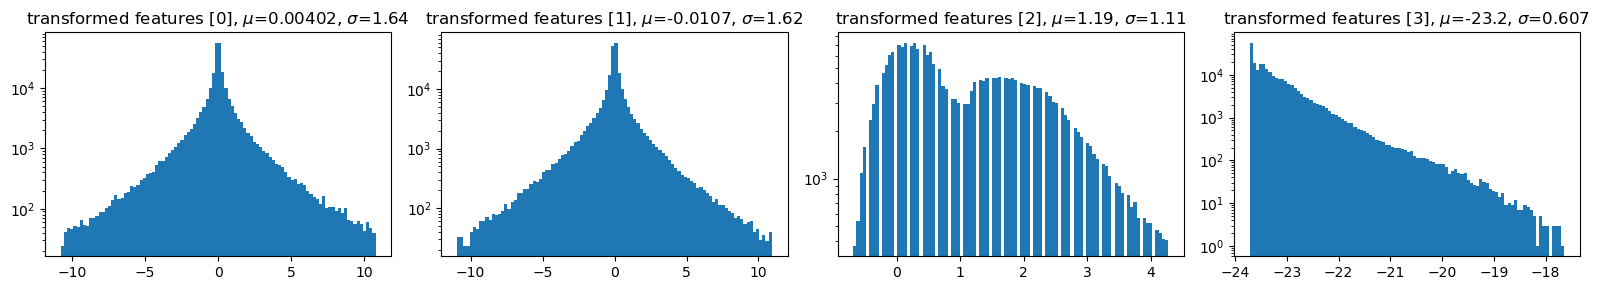

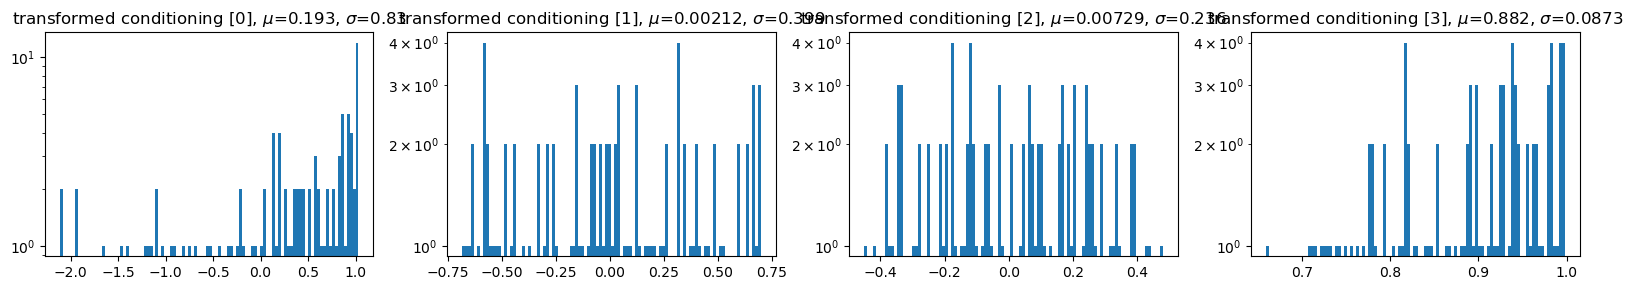

In [7]:
with torch.no_grad():
    features_t = feature_transform.forward(features.clone())
    cond_feats_t = cond_transform.forward(cond_feats.clone())

real_features_t = features_t[features[..., 3]>0]
plot_columns(real_features_t, "transformed features")
plot_columns(cond_feats_t, "transformed conditioning")
plt.show()

## Sanity check: inverse recovers the original data

In [8]:
with torch.no_grad():
    features_r = feature_transform.inverse(features_t.clone())
    cond_feats_r = cond_transform.inverse(cond_feats_t.clone())

print("features max abs diff:", (features - features_r).abs().max().item())
print("cond max abs diff:", (cond_feats - cond_feats_r).abs().max().item())

features max abs diff: 6.103515625e-05
cond max abs diff: 3.0517578125e-05


## Read the same data via correct dataset

``src/data/dataset.py`` provides an iterable ``torch.utils.data.Dataset``
that reads directly from the HDF5 files. Here we build it on the training
files and read a batch so we can compare the raw values to those produced
by ``read_raw_regaxes``.

In [9]:
# turn off the random fuzzing so the raw values are directly comparable
dataset_configs = copy.deepcopy(configs)
dataset_configs["training"]["retain_quantized"] = True

n_files = (
    dataset_configs["data"]["train_range_end"]
    - dataset_configs["data"]["train_range_start"]
)

dataset = dataset_from_config(
    dataset_configs,
    "train"
)

print("number of events in dataset:", len(dataset))
batch = dataset[len(dataset) // 2]
for name, value in batch.items():
    print(f"{name}: {np.asarray(value).shape}")

number of events in dataset: 1600000


ValueError: cannot reshape array of size 1 into shape (4)

## Compare the two readers

Both readers should agree on the point cloud values and the conditioning
features for the same events. We read the matching events with
``read_raw_regaxes`` and compare the distributions of the point columns.

In [ ]:
ds_features = to_tensor(batch["points"])
ds_cond = torch.concatenate([to_tensor(batch[name]) for name in configs["model"]["cond_features"]], dim=-1)

In [ ]:
print("dataset features shape:", tuple(ds_features.shape))
print("read_write points shape:", tuple(features.shape))


def real_points(points):
    flat = points.reshape(-1, points.shape[-1])
    return flat[flat[:, 3] > 0]


ds_real = real_points(ds_features)
rw_real = real_points(features)

n_cols = ds_real.shape[-1]
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 6))
axes = np.atleast_1d(axes)
for i, ax in enumerate(axes[0]):
    ax.hist(
        rw_real[:, i].detach().cpu().numpy(),
        bins=100,
        histtype="step",
        density=True,
        label="read_write",
    )
    ax.hist(
        ds_real[:, i].detach().cpu().numpy(),
        bins=100,
        histtype="step",
        density=True,
        label="dataset",
    )
    ax.set_title(f"point column [{i}]")
    ax.legend()
    ax.semilogy()
    
for i, ax in enumerate(axes[1]):
    ax.hist(
        cond_feats[:, i].detach().cpu().numpy(),
        bins=100,
        histtype="step",
        density=True,
        label="read_write",
    )
    ax.hist(
        ds_cond[:, i].detach().cpu().numpy(),
        bins=100,
        histtype="step",
        density=True,
        label="dataset",
    )
    ax.set_title(f"point column [{i}]")
    ax.legend()
fig.tight_layout()
plt.show()